In [9]:
from rt_utils import RTStructBuilder
import matplotlib.pyplot as plt

# Load existing RT Struct. Requires the series path and existing RT Struct path
rtstruct = RTStructBuilder.create_from(
  dicom_series_path="/home/zhaosheng/4dct/cao wu jun/Resp  3.0  B30f  40% Pi", 
  rt_struct_path="/home/zhaosheng/4dct/cao wu jun/ARIA RadOnc Structure Sets/RS.1.2.246.352.205.4627839360466632183.6908298268160168110.dcm", 
)

# View all of the ROI names from within the image
print(rtstruct.get_roi_names())


['BODY', 'GTVp']


In [7]:
import os
import pydicom

ds = pydicom.dcmread("/home/zhaosheng/4dct/cao wu jun/ARIA RadOnc Structure Sets/RS.1.2.246.352.205.4627839360466632183.6908298268160168110.dcm")


Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 170
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: RT Structure Set Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.2.246.352.205.4627839360466632183.6908298268160168110
(0002, 0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.246.352.70.2.1.7
-------------------------------------------------
(0008, 0012) Instance Creation Date              DA: '20190107'
(0008, 0013) Instance Creation Time              TM: '182814.516000'
(0008, 0016) SOP Class UID                       UI: RT Structure Set Storage
(0008, 0018) SOP Instance UID                    UI: 1.2.246.352.205.4627839360466632183.6908298268160168110
(0008, 0020) Study Date                          DA: '20181221'
(0008, 0030) Study Time                          TM: '

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



(512, 512, 127)
(512, 512, 127)


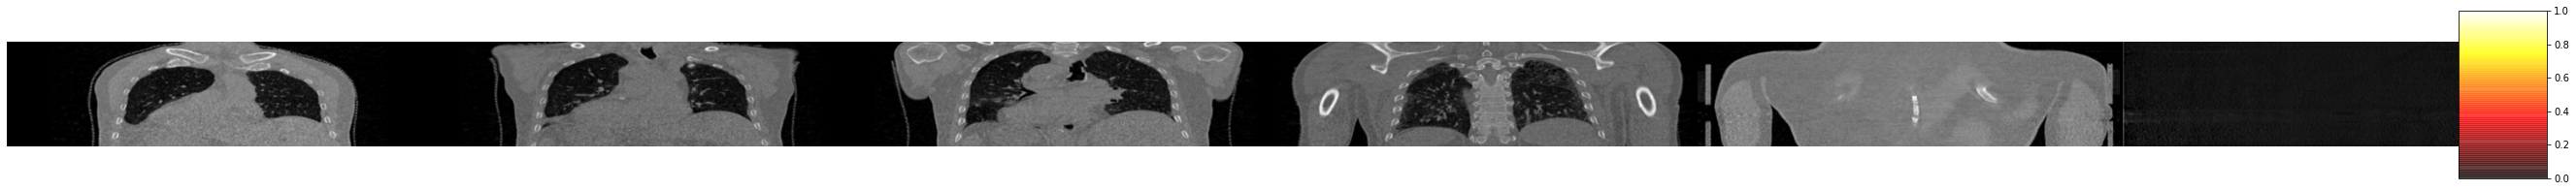

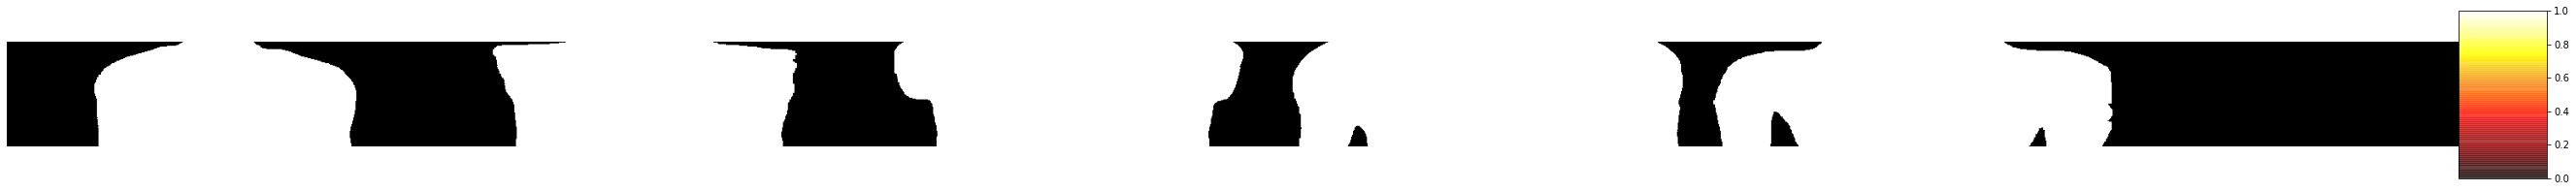

(512, 512, 127)
(512, 512, 127)


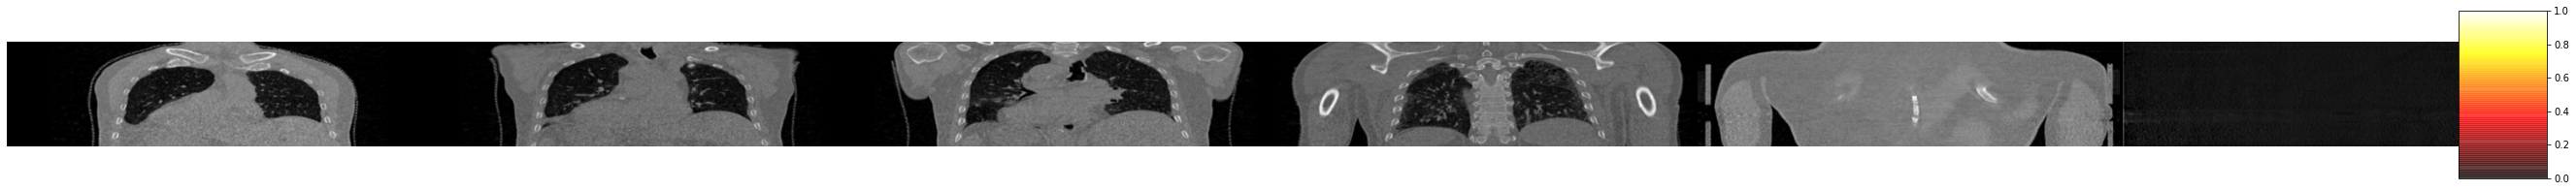

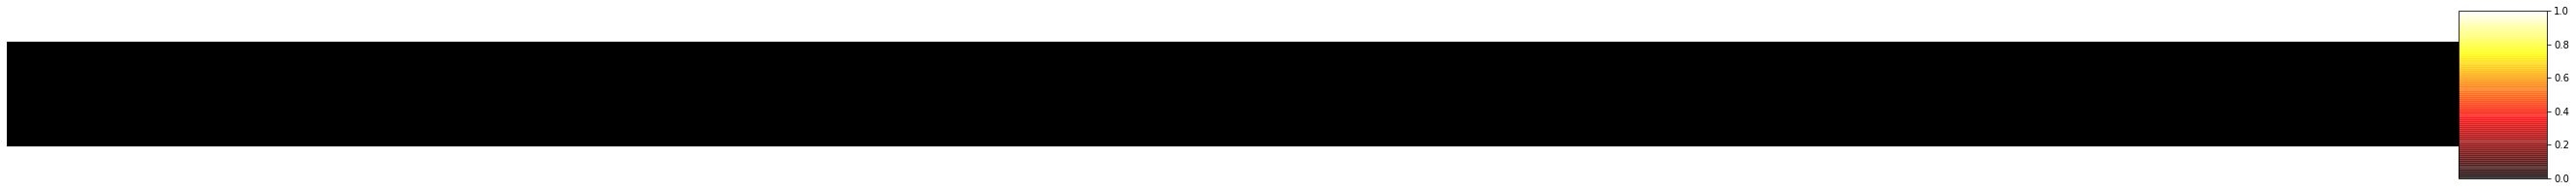

(512, 512, 127)


In [27]:
import os
import numpy as np
import ants
os.makedirs(f"./seg/",exist_ok=True,)

nii = "/home/zhaosheng/4dct_test_nii/caowujun/caowujun_t4.nii"
nii_img = ants.image_read(nii)
nii_img += 1000
print(nii_img.shape)
for organ in rtstruct.get_roi_names():
# Loading the 3D Mask from within the RT Struct
    mask_3d = rtstruct.get_roi_mask_by_name(organ).transpose(1,0,2)
    mask = np.zeros(mask_3d.shape)
    mask[mask_3d]=1
    mask_3d_img = ants.from_numpy(mask)
    print(mask_3d_img.shape)
    # mask_3d_img.plot()
    ants.plot(nii_img,cmap='gray',slices=[100,125,150,200,250,300],axis=1,overlay=mask_3d_img,overlay_cmap='hot',overlay_alpha=0.5,cbar=True)
    ants.plot(mask_3d_img,cmap='gray',slices=[100,125,150,200,250,300],axis=1,overlay=mask_3d_img,overlay_cmap='hot',overlay_alpha=0.5,cbar=True)
    #[150:370,100:320,50:150]
    # Display one slice of the region
    # first_mask_slice = mask_3d[:, :, 100]
    # plt.imshow(first_mask_slice)
    # plt.colorbar()
    # plt.title(organ)
    # plt.show()
    print(mask_3d.shape)
    np.save(f"./seg/_{organ}.npy",mask_3d)

In [2]:
import numpy as np
import os
import ants
import matplotlib.pyplot as plt
root="/home/zhaosheng/paper4/results0505"





for pname in sorted(os.listdir(root)):
    print(pname)
    
#         real_img.plot()
#         fake_img.plot()
#         fake_img.plot()
for pname in sorted(os.listdir(root)):
    print(pname)

caowujun
chenguangdeng
chenjinsheng
chenxiaosi
guixiufang
hanjianying
hexiaochun
huyannian
huzhiwen
jimeihong
jinyurong
licuihua
liuwansheng
liyifeng2
lubaimei
lvqingcheng
pengmeidi
yueshuqing


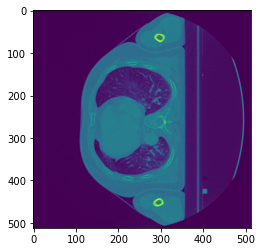

In [35]:
pname = "huzhiwen"
test = ants.image_read(f"/home/zhaosheng/4dct_test_nii/{pname}/{pname}_t5.nii").numpy()
plt.imshow(test[:,:,50])

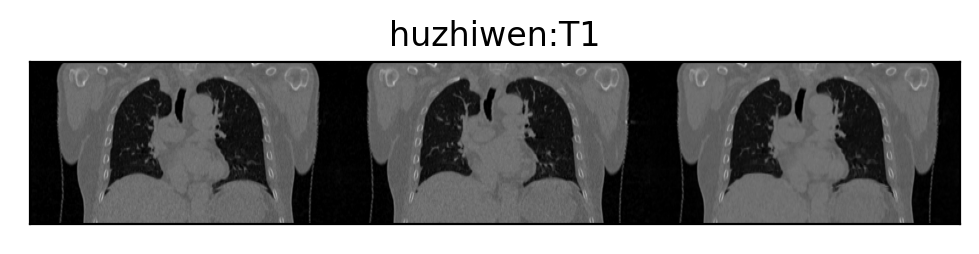

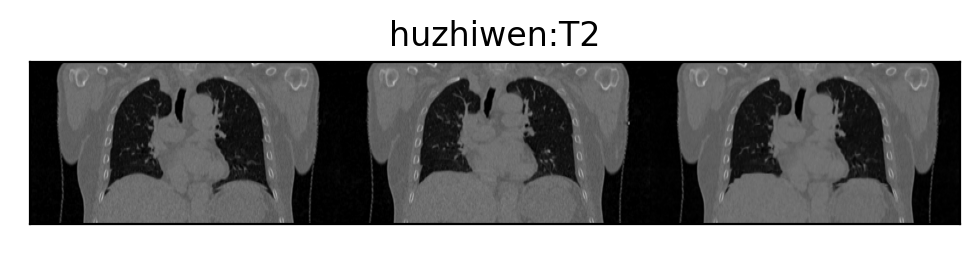

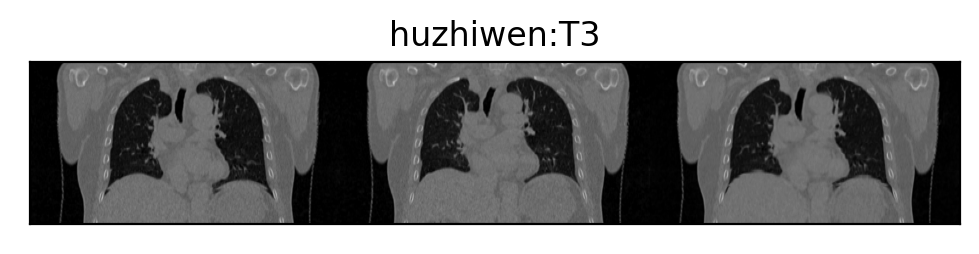

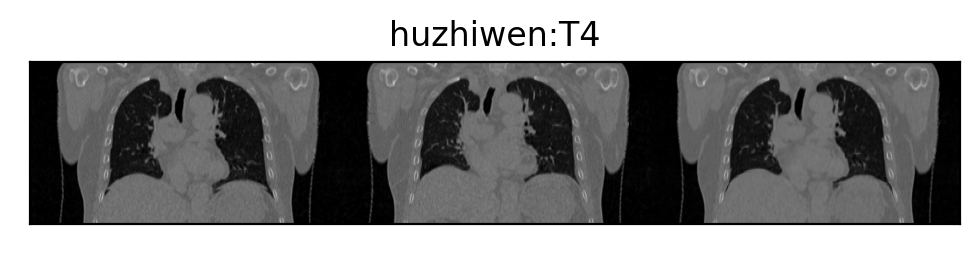

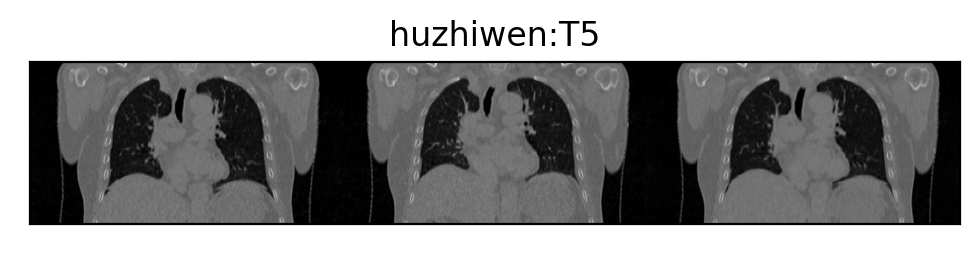

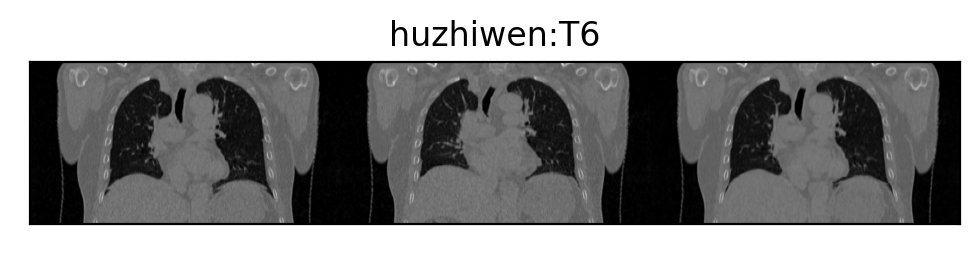

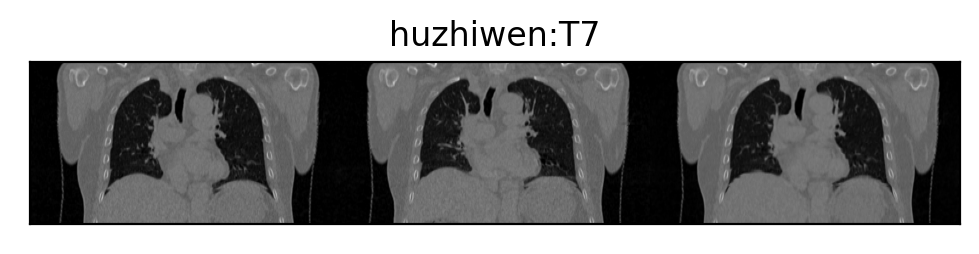

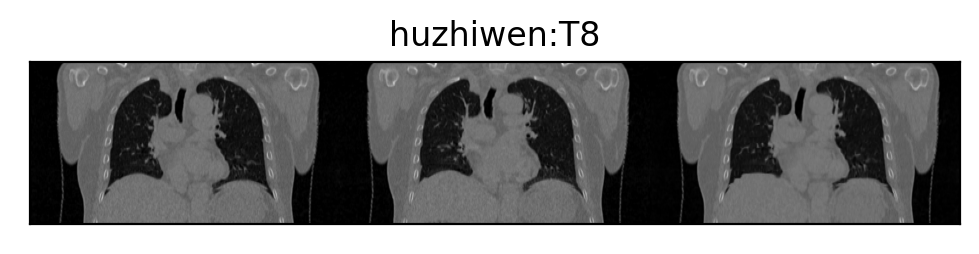

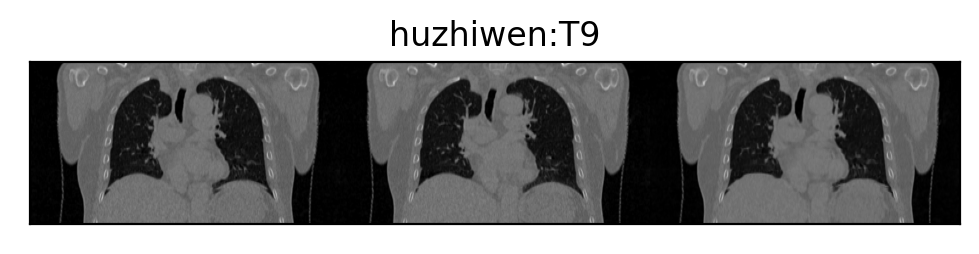

In [36]:

_slice = 240

def plot(array,ax,title,tumor=None):
    img = array.numpy()[:,200,::-1].transpose(1,0)
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    return 0

def getImage(_real,_slice):
    img = ants.image_read(_real[0])
    img = ants.resample_image(img,(img.spacing[0],img.spacing[1],img.spacing[2]/2.),False,1)
    
    return img[:,_slice,::-1].transpose(1,0)
    
for tindex in range(1,10):
    _real=[os.path.join(root,pname,_file) for _file in os.listdir(os.path.join(root,pname)) if "real_img_"+str(tindex) in _file]
    _fake=[os.path.join(root,pname,_file) for _file in os.listdir(os.path.join(root,pname)) if "fake_img_"+str(tindex) in _file]
    _input=[os.path.join(root,pname,_file) for _file in os.listdir(os.path.join(root,pname)) if "input_img_"+str(tindex) in _file]
    # print(_real)
    real_img = getImage(_real,_slice)
    fake_img = getImage(_fake,_slice)
    input_img = getImage(_input,_slice)
    _img = np.hstack([input_img,real_img,fake_img])

    plt.figure(dpi=200)
    plt.imshow(_img,cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title(f"{pname}:T{tindex}")
    # plot(input_img,plt.subplot(1,3,1),f"{pname}:T{tindex} Fixed")
    # plot(real_img,plt.subplot(1,3,2),f"{pname}:T{tindex} Moving")
    # plot(fake_img,plt.subplot(1,3,3),f"{pname}:T{tindex} Fake")
    os.makedirs(f"./pngs/{pname}/",exist_ok=True)
    plt.savefig(f"./pngs/{pname}/{tindex}.png")
    plt.show()

In [21]:
mkdir pngs

In [9]:
transpose

/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.

